In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))
from src.models.train_model import load_data, split_data, develop_model
from src.models.predict_model import predict, evaluate_model,get_feature_importance,get_threshold_r2
from src.visualization.visualize import plot_score_comparison_chart

sys.path.append('..')

%load_ext autoreload
%autoreload 2

# 1. Load Preprocessed Data


In [3]:
df = load_data()
df.head(3)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_sin,nsm_cos,is_weekend,nsm_sin_loadtype,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,...,0.065403,0.997859,0,0.065403,0.997859,2.95,lagging_dominant,26.79,79.0305,1
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,...,0.130526,0.991445,0,0.130526,0.991445,4.46,lagging_dominant,33.23,148.2058,1
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,...,0.195090,0.980785,0,0.195090,0.980785,3.28,lagging_dominant,29.72,97.4816,1


In [4]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 24 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Usage_kWh                                    35040 non-null  float64
 1   Lagging_Current_Reactive.Power_kVarh         35040 non-null  float64
 2   Leading_Current_Reactive_Power_kVarh         35040 non-null  float64
 3   Lagging_Current_Power_Factor                 35040 non-null  float64
 4   Leading_Current_Power_Factor                 35040 non-null  float64
 5   NSM                                          35040 non-null  int64  
 6   WeekStatus                                   35040 non-null  str    
 7   Day_of_week                                  35040 non-null  str    
 8   Load_Type                                    35040 non-null  str    
 9   consumed_date                                35040 non-null  str    
 10  Lagging_C

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor',
       'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week',
       'Load_Type', 'consumed_date',
       'Lagging_Current_Reactive.Power_kVarh_logged',
       'Leading_Current_Reactive_Power_kVarh_logged',
       'Lagging_Current_Power_Factor_logged',
       'Leading_Current_Power_Factor_logged', 'nsm_sin', 'nsm_cos',
       'is_weekend', 'nsm_sin_loadtype', 'nsm_cos_loadtype', 'total_reactive',
       'reactive_mode', 'pf_loss', 'electrical_load', 'near_unity_pf'],
      dtype='str')

# 2. Model Development

## 2.1 Select Forecast-safe features

I exclude physical-leak features which are same-window electrical readings `Lagging_Current_Reactive.Power_kVarh_logged`, `Leading_Current_Reactive_Power_kVarh_logged`, `pf_loss`, `total_reactive`.

In [ ]:
# TO DO:Make sure consumed_date is in date data type. so that can use timeseries pattern in modeling

df['consumed_date'].dtype

dtype('<M8[us]')

In [4]:
target = 'Usage_kWh'

# all features = original + new
# features = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
#        'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor',
#        'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week',
#        'Load_Type', 'consumed_date',
#        'Lagging_Current_Reactive.Power_kVarh_logged',
#        'Leading_Current_Reactive_Power_kVarh_logged', 'nsm_sin', 'nsm_cos',
#        'is_weekend', 'nsm_sin_loadtype', 'nsm_cos_loadtype', 'total_reactive',
#        'reactive_mode', 'pf_loss', 'electrical_load', 'near_unity_pf']

# forecast-safe features
features = ['nsm_sin', 'nsm_cos','nsm_sin_loadtype', 'nsm_cos_loadtype', 'is_weekend','electrical_load']

num_cols = df[features].select_dtypes(include='number').columns.tolist()
cat_cols = df[features].select_dtypes(include=['str', 'category']).columns.tolist()

num_feature = [col for col in num_cols if col != target]
cat_feature = [col for col in cat_cols if col != target]

selected_features = num_feature + cat_feature



## 2.2 Split data to define test set

I decided to split by time(column - `consumed_date`) instead of randomly.
Test set will be the  most recent 'test size' fraction of the data so it represents genuiely unseen future period rather than time-adjacent neighbors of training data row.


In [5]:
# Split data
split_by_col = 'consumed_date'
test_size = 0.3

df_train, df_test = split_data(df,split_by_col,test_size)
print(f"Size of training dataset: {df_train.shape[0]} rows")
print(f"Size of test dataset: {df_test.shape[0]} rows")

X_train, y_train = df_train[selected_features], df_train[target]
X_test, y_test  = df_test[selected_features], df_test[target]


Size of training dataset: 24528 rows
Size of test dataset: 10512 rows


## 2.1 Base Model - Linear Regression
### 2.1.1 Train Model

In [6]:
# train model
model_base = LinearRegression()
param_grid = {
            'regressor__fit_intercept': [True,False]
        }
pipeline_linear, best_params, best_cv_score_linear = develop_model(model_base, param_grid,num_feature, cat_feature, X_train, y_train)


<class 'sklearn.linear_model._base.LinearRegression'>
Best parameters found: {'regressor__fit_intercept': True}
Best score: 0.537


### 2.1.2 Predict

In [23]:
# predict
if pipeline_linear is not None:
    y_pred_linear = predict(pipeline_linear,X_test)
    print(y_pred_linear)
else:
    print(f"Unable to get base model.")

[92.56667925 37.62197933 38.95464245 ... 15.27981712 12.02110245
 10.51330069]


### 2.1.3 Evaluate model

In [ ]:
# evaluate model
if y_pred_linear is not None:
    result_linear = evaluate_model(y_test, y_pred_linear)
    print(np.isclose(result_linear['rmse'], np.sqrt(result_linear['mse'])))  # True
else:
    print(f"Unable to get predicted result.")

R² Score: 0.6171
Mean Squared Error: 365.7521
Root Mean Squared Error: 19.1246
Mean Absolute Error:14.4552
True


## 2.2 Compare Model - Random Forest Regressor
### 2.2.1 Train model


In [9]:
# train model
model_rdf = RandomForestRegressor()
param_grid = {
            'regressor__n_estimators': [50],
            'regressor__max_depth': [ 10],
            'regressor__min_samples_split': [ 5]
        }
pipeline_rdf, best_params, best_cv_score_rdf = develop_model(model_rdf,param_grid,num_feature, cat_feature, X_train, y_train)


<class 'sklearn.ensemble._forest.RandomForestRegressor'>
Best parameters found: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 50}
Best score: 0.814


### 2.2.2 Predict

In [10]:
# predict
if pipeline_rdf is not None:
    y_pred_rdf = predict(pipeline_rdf,X_test)
    print(y_pred_rdf)
else:
    print(f"Unable to get model.")

[80.65193275  5.161877    6.47532978 ...  3.82758841  3.82758841
  3.82758841]


### 2.2.3 Evaluate Model

In [11]:
# evaluate model
if y_pred_rdf is not None:
    result_rdf = evaluate_model(y_test, y_pred_rdf)
    print(np.isclose(result_rdf['rmse'], np.sqrt(result_rdf['mse'])))  # True
else:
    print(f"Unable to get predicted result.")

R² Score: 0.7261
Mean Squared Error: 261.6193
Root Mean Squared Error: 16.1747
Mean Absolute Error:9.2092
True


## 2.3 Compare Model 2 - XGBoost

### 2.3.1 Train model

In [12]:
# train model
model_xgb = xgb.XGBRegressor()

param_grid = {
  'regressor__max_depth': [3, 5, 7],
  'regressor__learning_rate': [0.1, 0.01, 0.05],
  'regressor__n_estimators': [50, 100, 200]
}

pipeline_xgb, best_params, best_cv_score_xgb = develop_model(model_xgb,param_grid,num_feature, cat_feature, X_train, y_train)

<class 'xgboost.sklearn.XGBRegressor'>
Best parameters found: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Best score: 0.82


### 2.3.2 Predict

In [13]:
# predict
if pipeline_xgb is not None:
    y_pred_xgb = predict(pipeline_xgb,X_test)
    print(y_pred_xgb)
else:
    print(f"Unable to get model.")

[78.34454    4.9167223  6.170805  ...  3.6887684  3.6596463  3.6596463]


### 2.3.3 Evaluate Model

In [14]:
# evaluate model
if y_pred_xgb is not None:
    result_xgb = evaluate_model(y_test, y_pred_xgb)
    print(np.isclose(result_xgb['rmse'], np.sqrt(result_xgb['mse'])))  # True
else:
    print(f"Unable to get predicted result.")

R² Score: 0.721
Mean Squared Error: 266.5207
Root Mean Squared Error: 16.3255
Mean Absolute Error:9.5117
True


# 3. Score Comparison

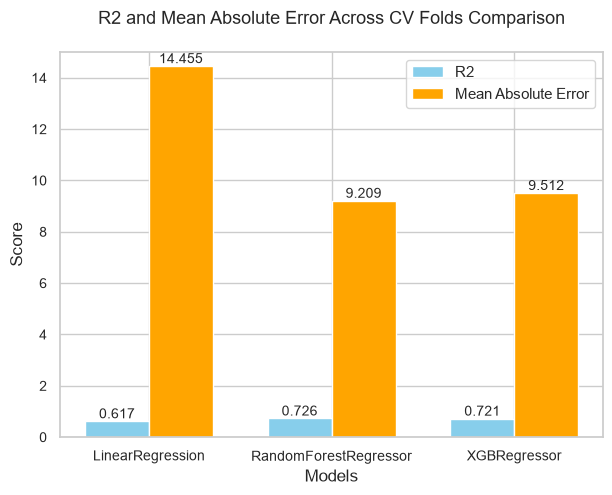

In [17]:
models = [pipeline_linear.named_steps['regressor'].__class__.__name__, pipeline_rdf.named_steps['regressor'].__class__.__name__, pipeline_xgb.named_steps['regressor'].__class__.__name__]
r2_list = [result_linear['r2'], result_rdf['r2'], result_xgb['r2']]
mae_list = [result_linear['mae'],result_rdf['mae'],result_xgb['mae']]

plot_score_comparison_chart(models,r2_list, mae_list)


# 4. Finding the feature importance
I extract features names from the preprocessing steps to get feature importance.

# 4.1 Feature Importance in Linear Regression

            feature  Importance
5   electrical_load   14.531124
3  nsm_cos_loadtype   11.586158
0           nsm_sin    7.865374
2  nsm_sin_loadtype    6.931376
4        is_weekend    6.018660
1           nsm_cos    1.877709


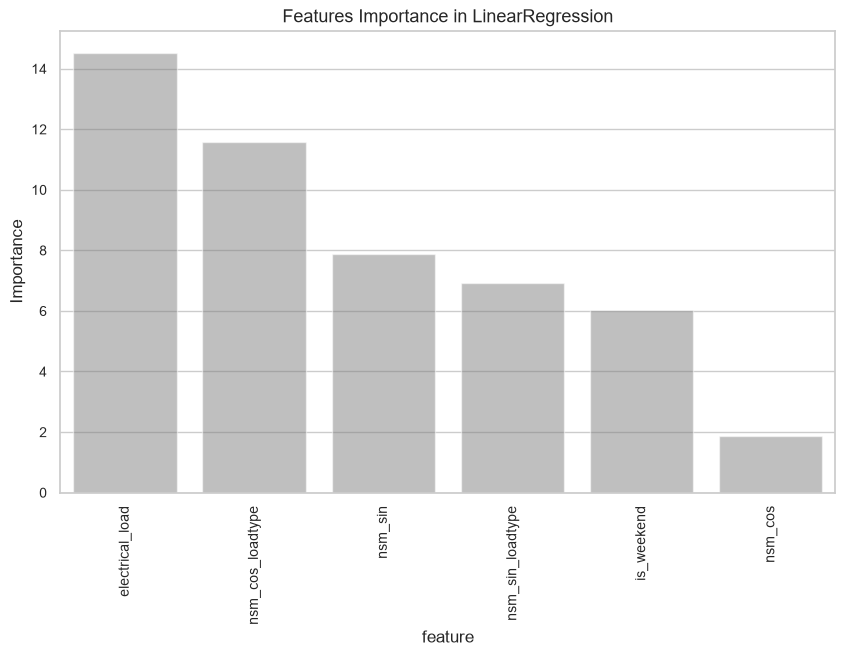

In [18]:
model_name = pipeline_linear.named_steps['regressor'].__class__.__name__
feature_importances_linear = get_feature_importance(pipeline_linear, model_name)

# 4.2 Feature Importance in Random Forest Regressor

            feature  Importance
5   electrical_load    0.545707
2  nsm_sin_loadtype    0.197396
3  nsm_cos_loadtype    0.182171
0           nsm_sin    0.039054
1           nsm_cos    0.031331
4        is_weekend    0.004341


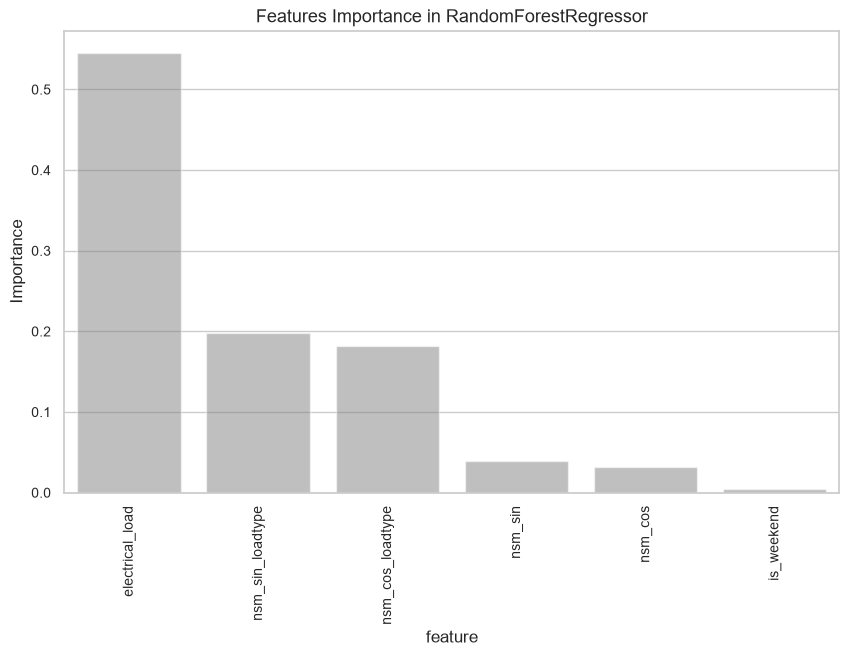

In [19]:
model_name = pipeline_rdf.named_steps['regressor'].__class__.__name__
feature_importances_rdf = get_feature_importance(pipeline_rdf, model_name)

# 4.3 Feature Importance in XGBoost Regressor

            feature  Importance
3  nsm_cos_loadtype    0.332174
2  nsm_sin_loadtype    0.287324
5   electrical_load    0.242273
0           nsm_sin    0.062924
1           nsm_cos    0.059422
4        is_weekend    0.015882


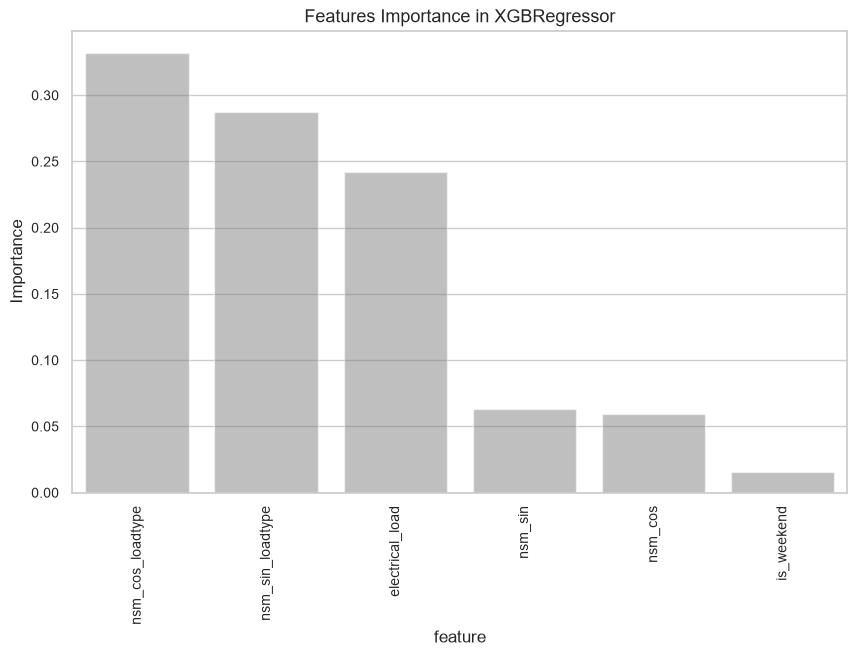

In [20]:
model_name = pipeline_xgb.named_steps['regressor'].__class__.__name__
feature_importances_xgb = get_feature_importance(pipeline_xgb, model_name)

# 4.4 Importance Features

In [21]:
top_feature_linear = pd.DataFrame({'Model': 'Linear', 'Feature':feature_importances_linear.iloc[:3]['feature'] })
top_feature_rdf = pd.DataFrame({'Model': 'RDF', 'Feature':feature_importances_rdf.iloc[:3]['feature'] })
top_feature_xgb = pd.DataFrame({'Model': 'XGB', 'Feature':feature_importances_xgb.iloc[:3]['feature'] })

all_imp_features = pd.concat([top_feature_linear, top_feature_rdf, top_feature_xgb])

print(all_imp_features.to_markdown())

|    | Model   | Feature          |
|---:|:--------|:-----------------|
|  5 | Linear  | electrical_load  |
|  3 | Linear  | nsm_cos_loadtype |
|  0 | Linear  | nsm_sin          |
|  5 | RDF     | electrical_load  |
|  2 | RDF     | nsm_sin_loadtype |
|  3 | RDF     | nsm_cos_loadtype |
|  3 | XGB     | nsm_cos_loadtype |
|  2 | XGB     | nsm_sin_loadtype |
|  5 | XGB     | electrical_load  |


# 5. Evaluation By Business Requirement

Let's assume business context and thresholds are as following; 

**Business KPI Table**
| Metric | Business Meaning | Target/Threshold
| --- | --- | --- |
| R2  | Explains usage patterns using only forecast-safe (pre-consumption) features | >= 0.75
| MAE | Average prediction error, vs naive persistence baseline | ≥ 30% improvement over baseline
| MAE by Load_Type | Consistency of error across Light/Medium/Maximum load |  No class > 1.5× overall MAE
| MAE (weekday − weekend) | Error stability across day types | < 5 kWh




## 5.1 Evaluation Metric - R2

In [25]:
r2_threshold = 0.75
best_r2 = get_threshold_r2(r2_list,r2_threshold)
best_r2

[]

TO DO
Reconsider adding new features which is/are related to time-series. Check Claude AI suggestion